In [1]:
import numpy as np
from typing import Any
from lf_toolkit.evaluation import Result, Params

In [2]:
import os
import json

cwd = os.getcwd()
dir = os.path.dirname(cwd)
reference_path = os.path.join(dir, "data", "referenceMIDI.json")
response_path = os.path.join(dir, "data", "responseMIDI.json")

with open(reference_path) as f1:
    reference = json.load(f1)

with open(response_path) as f2:
    response = json.load(f2)

# Note Alignment techniques

## DTW

The goal of the note alignment is to find if the student played any missing or extra notes, and which note is missing/extra.


Based on the findings during the project plan phase, DTW is commonly used for alignment. The algorithm can be found in this book (Chpater 3.2 Dynamic Time Warping):
M. Müller, Fundamentals of Music Processing. Cham: Springer International Publishing, 2021, ISBN: 9783030698072. DOI:https://doi.org/10.1007/978-3-030-69808-9.

In general, this DTW algorithm finds an optimal possibly nonlinear alignment between response MIDI sequence to reference MIDI sequence.

Basic approach:
- Evaluating the local cost measure for each pair of elements in the response(X) and reference(Y) sequences. 
- Dynamic programming to find an alignment path between X and Y having minimal overall cost, i.e. DTW distance. The algorithm computes a cumulative distance path, the timestamps of the target MIDI are warped so they perfectly align with the anchor points of the reference MIDI.


However, this basic approach will not correctly handle the missing note case as expected, because it allows a note to match with multiple notes, and each note must be paired. Let's say, there is a note missing in the response, this algorithm tends to match a response note with two reference note, instead of reporting the missing problem.

! need to modify this algorithm to make it handle the missing/extra problem correctly. Cosider analysing each entry of the warping path.

In [ ]:
def compute_cost(note1, note2):
    """
    Compute the local cost measure for each pair of notes.
 
    Only pitch is involved in the cost calculation, since the purpose 
    is to pair up notes with similar pitches.
 
    Args:
        note1: dict with keys "pitch" (int), "start" (float), "duration" (float)
        note2: dict with keys "pitch" (int), "start" (float), "duration" (float)
 
    Returns:
        int: cost value >= 0 (lower means more similar pitch)
    """
    return int(abs(note1["pitch"] - note2["pitch"]))


def note_alignment_DTW(response_notes, ref_notes):
    """
    DTW pipeline: build cost matrix C -> build accumulated cost matrix D 
    -> backtrack to find the optimal warping path
    - the Rows of C and D correspond to response notes
    - the Columns of C and D correspond to reference notes
    
    Args:
        response_notes: The student's response MIDI notes to evaluate
        ref_notes: The reference MIDI note
 
    Returns:
        path: list of (response_idx, reference_idx) pairs — the optimal alignment
        C: local cost matrix
        D: accumulated cost matrix
    """

    N = len(response_notes)
    M = len(ref_notes)

    # step1: Build the local cost matrix C of size (N x M).
    # C[i, j] = note_cost(ref_notes[i], response_notes[j])
    C= np.zeros((N, M))
    for i in range(N):
        for j in range(M):
            C[i, j] = compute_cost(response_notes[i], ref_notes[j])

    # step2: Build the accumulated cost matrix D of size (N+1 x M+1)
    # using small trick for simplifying the initialization
    # D[n, 0] = inf  for n >= 1
    # D[0, m] = inf  for m >= 1
    D = np.full((N + 1, M + 1), np.inf)
    D[0, 0] = 0
    # for all n in [1..N] and m in [1..M]:
    # D[i, j] = C[i, j] + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            D[i, j] = C[i - 1, j - 1] + min(
                D[i - 1, j], # vertical step, multiple response notes are mapped to the same ref note
                D[i, j - 1], # horizontal step, same response note is reused for multiple ref notes
                D[i - 1, j - 1]) # diagonal step

    # step3: Backtrack through the D to find the optimal warping path P
    path = []
    n, m = N, M
    while n > 0 and m > 0:
        path.append((n-1, m-1))
        # Find the minimum cost step
        diag = D[n-1, m-1]
        vertical = D[n-1, m]
        horizontal = D[n, m-1]
        min_step = min(diag, vertical, horizontal)
        if min_step == vertical:
            n -= 1
        elif min_step == horizontal:
            m -= 1
        else: # diagonal step
            n -= 1
            m -= 1
    # Reverse to get the path from start to end
    path.reverse()  

    return path, C, D


def path_classification(path, C):
    """
    Classify the each entry of the alignment path into:
    - correct: response pitch matches reference pitch (cost = 0)
    - wrong: response pitch differs from reference pitch, but all the parings are one-to-one (cost > 0)
    - missing: same response pitch is mapped to multiple reference pitches 
    - extra: multiple response pitches are mapped to the same reference pitch
 
    Args:   
    path: list of (response_idx, reference_idx) pairs from the backtrack warping path
    C: local cost matrix (N x M)

    Returns:
        list of event dicts, each one of:
            {'type': 'match' or 'replacement' or 'missing' or 'extra', 
            'response_idx': int, 'reference_idx': int, 'cost': int}
    """

Evaluation

In [ ]:
def evaluate_note_pair(response_note, ref_note, reference_idx,
                       timing_tolerance=0.1, duration_tolerance=0.1):
    """
    Evaluate a single aligned note pair and return feedback.
 
    Args:
        response_note: student's note dict
        ref_note: reference note dict
        reference_idx: 1-based display index (based on ref position)
        timing_tolerance: consider as correct if start is within this tolerance
        duration_tolerance: consider as correct if duration is within this tolerance
 
    Returns:
        is_correct (bool), feedback (list of str)
    """
    feedback = []
    is_correct = True
 
    # Pitch check
    if response_note["pitch"] != ref_note["pitch"]:
        is_correct = False
        feedback.append(
            f"Note {reference_idx}: wrong pitch — expected {ref_note['pitch']}, "
            f"played {response_note['pitch']}."
        )
 
    # Timing check
    timing_diff = abs(response_note["start"] - ref_note["start"])
    if timing_diff > timing_tolerance:
        is_correct = False
        feedback.append(f"Note {reference_idx}: difference in start time: {timing_diff:.2f}s.")
 
    # Duration check
    duration_diff = abs(response_note["duration"] - ref_note["duration"])
    if duration_diff > duration_tolerance:
        is_correct = False
        feedback.append(f"Note {reference_idx}: difference in duration: {duration_diff:.2f}s.")
 
    if is_correct:
        feedback.append(f"Note {reference_idx} (with pitch {ref_note['pitch']}) is correct.")
 
    return is_correct, feedback

In [ ]:
def comparison(response, ref,
                   timing_tolerance=0.1, duration_tolerance=0.1):
    """
    Compare student MIDI against reference MIDI after DTW-based alignment.
 
    Args:
        response: The student's response MIDI
        ref: The reference MIDI
        timing_tolerance:   seconds
        duration_tolerance: seconds
 
    Returns:
        all_correct (bool), feedback (list of str)
    """
    response_notes = response["notes"]
    ref_notes = ref["notes"]
 
    # Align using DTW — response first, ref second
    path, C, D = note_alignment_DTW(response_notes, ref_notes)
 
    feedback = []
    all_correct = True
    
    for response_idx, reference_idx in path:
        is_correct, feedback = evaluate_note_pair(
            response_notes[response_idx], ref_notes[reference_idx],
            reference_idx=reference_idx + 1,
            timing_tolerance=timing_tolerance,
            duration_tolerance=duration_tolerance,
        )
        if not is_correct:
            all_correct = False
        feedback.extend(feedback)
 
    return all_correct, feedback

In [ ]:
def evaluation_function(response: Any, answer: Any, params: Params) -> Result:
    """
    Entry point for Lambda Feedback.
 
    Args:
        response: student MIDI dict
        answer:   reference MIDI dict
        params:   optional extra parameters
 
    Returns:
        Result with is_correct and feedback string
    """
    all_correct, feedback = comparison(response, answer)
    return Result(
        is_correct=all_correct,
        feedback_items=[("feedback", "\n".join(feedback))]
    )

In [ ]:
is_correct, feedbacks = comparison(
    response,
    reference
)

print(is_correct)

for feedback in feedbacks:
    print(feedback)

False
Note 1 (with pitch 60) is correct.
Note 2: wrong pitch — expected 62, played 63.
Note 3: difference in start time: 0.15s.
Note 4: difference in duration: 0.20s.
Note 5: wrong pitch — expected 67, played 65.
Note 5: difference in start time: 0.70s.
Note 5: difference in duration: 0.20s.


note5 should be a missing pitch!! Need to check the DTW algorithm!

## Edit Distance

a simplified version of this is applied here: https://www.math.univ-toulouse.fr/~mongeau/music.pdf 

Unlike standard DTW where off-diagonal moves has no cost and every note must be aligned to another, the Edit-distance approach allows a note to be explicitly left unaligned at the cost of gap_penalty, i.e. insertion represents an extra note, deletion represents a missing note, the moving direction during backtracking has an unambiguous meaning (diagonal = match/replacement, vertical = extra, horizontal = missing), we can classify each operation directly during backtracking.

In [3]:
def normalize_start_times(notes):
    """
    Shift all notes so that the first note starts at t=0.
 
    Args:
        notes: list of note dicts, each with at least a "start" key.
 
    Returns:
        A new list of note dicts (copies, not the original objects), with
        every "start" value shifted so notes[0]["start"] == 0. Returns an
        empty list unchanged if notes is empty.
    """
    if not notes:
        return []
 
    first_start = notes[0]["start"]
 
    shifted_notes = []
    for note in notes:
        # Create a copy of the note dict with the "start" time shifted
        note_copy = {
            "pitch": note["pitch"],
            "start": note["start"] - first_start,
            "duration": note["duration"],
        }
        shifted_notes.append(note_copy)
 
    return shifted_notes

In [4]:
def compute_cost(note1, note2):
    """
    Cost of aligning (replacing) one note with another, based on pitch.
 
    cost = 0: pitches are identical (a 'match'). 
    cost > 0: different pitches (a 'replacement')
 
    Args:
        note1: dict with keys "pitch" (int), "start" (float), "duration" (float)
        note2: dict with keys "pitch" (int), "start" (float), "duration" (float)
 
    Returns:
        int: cost value >= 0 (lower means more similar pitch)
    """
    return int(abs(note1["pitch"] - note2["pitch"]))


def note_alignment_ED(response_notes, ref_notes, gap_penalty=6):
    """
    Align notes using edit distance (ED). 
    The ED allows for insertions and deletions, which can be useful for 
    evaluating musical practice containing missing/extra notes.
    
    Args:
        response_notes: The student's response MIDI notes to evaluate
        ref_notes: The reference MIDI note
        gap_penalty: cost of leaving a note unaligned (insertion/deletion)
 
    Returns:
        operations: list of transformation ops dicts, in order from first note to last:
            {'type': 'match' or 'replacement' or 'missing' or 'extra', 
            'response_idx': int or None, 
            'reference_idx': int or None, 
            'cost': int}
        D: accumulated cost matrix, shape (N+1, M+1)
    """
    # the rows of D correspond to response notes
    N = len(response_notes)
    # the columns of D correspond to reference notes
    M = len(ref_notes)

    # Build the accumulated cost matrix D of size (N+1 x M+1)
    D = np.zeros((N + 1, M + 1), dtype=int)
    # Boundary conditions: aligning against an empty sequence means every note
    # is unaligned, so the cost is n (or m) times the gap penalty.
    for n in range(1, N + 1):
        D[n, 0] = n * gap_penalty # n extra response notes
    for m in range(1, M + 1):
        D[0, m] = m * gap_penalty # m missing ref notes
    # Recursion (accumulated cost / score matrix D):
    for n in range(1, N + 1):
        for m in range(1, M + 1):
            replace_cost = compute_cost(response_notes[n-1], ref_notes[m-1])
            D[n, m] = min(
                D[n-1, m-1] + replace_cost, # diagonal: match or replacement
                D[n-1, m] + gap_penalty, # vertical: extra note response[n-1]
                D[n, m-1] + gap_penalty, # horizontal: missing response for ref[m-1]
            )

    # Backtrack, classify each transformation ops based on movement direction in D
    operations = []
    n, m = N, M
    while n > 0 or m > 0:
        # boundary conditions: if we are at the most top row or left column, we can only move in one direction
        # at the top row, only horizontal moves possible
        if n == 0: 
            # missing response for ref[m-1] (deletion)
            operations.append({"type": "missing", "response_idx": None,
                            "reference_idx": m - 1, "cost": gap_penalty})
            m -= 1
        # at the most left column, only vertical moves possible
        elif m == 0: 
            # extra note response[n-1] (insertion)
            operations.append({"type": "extra", "response_idx": n - 1,
                            "reference_idx": None, "cost": gap_penalty})
            n -= 1
        # for all other cases, we can move in any direction (diagonal, vertical, horizontal)
        else:
            replace_cost = compute_cost(response_notes[n-1], ref_notes[m-1])
            diag = D[n-1, m-1] + replace_cost # diagonal: match or replacement
            up = D[n-1, m] + gap_penalty # vertical: extra note response[n-1]
            left = D[n, m-1] + gap_penalty # horizontal: missing response for ref[m-1]
            min_cost = min(diag, up, left) # find the minimum cost step
            # classify the transformation ops based on the minimum cost step
            if min_cost == diag: # diagonal -> two notes are aligned (match/replacement)
                operations.append({
                    "type": "match" if replace_cost == 0 else "replacement",
                    "response_idx": n - 1,
                    "reference_idx": m - 1,
                    "cost": replace_cost,
                })
                n, m = n - 1, m - 1
            elif min_cost == up: # vertical -> response[n-1] is extra (insertion)
                operations.append({"type": "extra", "response_idx": n - 1,
                                "reference_idx": None, "cost": gap_penalty})
                n -= 1
            else: # horizontal -> response is missing for ref[m-1] (deletion)
                operations.append({"type": "missing", "response_idx": None,
                                "reference_idx": m - 1, "cost": gap_penalty})
                m -= 1
 
    operations.reverse() # reverse the operations to get them in order from first note to last
    return operations, D

TODO: The gap_penaulty need careful consideration! To be modified.

# Feedback generation

#### Version 1.0

In [ ]:
def generate_feedback(operations, response_notes, ref_notes,
                       timing_tolerance=0.1, duration_tolerance=0.1):
    """
    Evaluate the response MIDI and return feedback.
    For 'match'/'replacement' operations, checks pitch, timing, and duration
    of the aligned pair. 
    For 'missing'/'extra' operations, reports the note directly
 
    Args:
        operations: list of transformation ops dicts
        response_notes: list of note dicts from student's performance
        ref_notes: list of note dicts from reference performance
        timing_tolerance: consider as correct if start is within this tolerance
        duration_tolerance: consider as correct if duration is within this tolerance
 
    Returns:
        is_correct (bool), feedback (list of str)
    """

    feedback = []
    is_correct = True

    for op in operations:
        if op["type"] in ("match", "replacement"):
            response_note = response_notes[op["response_idx"]]
            ref_note = ref_notes[op["reference_idx"]]
            reference_idx = op["reference_idx"] + 1   # 1-based for display
            correct_note = True

            # Pitch check
            if response_note["pitch"] != ref_note["pitch"]:
                correct_note = False
                feedback.append(
                    f"Note {reference_idx}: wrong pitch — expected {ref_note['pitch']}, "
                    f"played {response_note['pitch']}."
                )
        
            # Timing check
            timing_diff = abs(response_note["start"] - ref_note["start"])
            if timing_diff > timing_tolerance:
                correct_note = False
                feedback.append(f"Note {reference_idx}: difference in start time: {timing_diff:.2f}s.")
        
            # Duration check
            duration_diff = abs(response_note["duration"] - ref_note["duration"])
            if duration_diff > duration_tolerance:
                correct_note = False
                feedback.append(f"Note {reference_idx}: difference in duration: {duration_diff:.2f}s.")

            if correct_note:
                feedback.append(f"Note {reference_idx} (pitch {ref_note['pitch']}) is correct.")
            else:
                is_correct = False
        
        elif op["type"] == "missing":
            is_correct = False
            reference_idx = op["reference_idx"]
            feedback.append(
                f"Note {reference_idx + 1} (pitch {ref_notes[reference_idx]['pitch']}) "
                f"is missing in your performance."
            )
 
        elif op["type"] == "extra":
            is_correct = False
            response_note = response_notes[op["response_idx"]]
            feedback.append(
                f"Extra note played: pitch {response_note['pitch']} "
                f"at t={response_note['start']:.2f}s (not in reference)."
            )
 
    return is_correct, feedback


def compare_performance(responseMIDI, refMIDI, gap_penalty=6,
                        timing_tolerance=0.1, duration_tolerance=0.1):
    """
    Compare student MIDI against reference MIDI
 
    Args:
        responseMIDI: student's response MIDI dict
        refMIDI: reference MIDI dict
        gap_penalty: cost of leaving a note unaligned
        timing_tolerance: consider as correct if start is within this tolerance
        duration_tolerance: consider as correct if duration is within this tolerance
 
    Returns:
        all_correct (bool), feedback (list of str)
    """
    response_notes = responseMIDI["notes"]
    ref_notes      = refMIDI["notes"]
 
    # Step 1: align using edit distance with gap penalty,
    # emitting match/replacement/missing/extra operations directly
    operations, D = note_alignment_ED(response_notes, ref_notes, gap_penalty)
 
    # Step 2: turn the alignment operations into feedback messages
    all_correct, feedback = generate_feedback(
        operations, response_notes, ref_notes,
        timing_tolerance=timing_tolerance,
        duration_tolerance=duration_tolerance,
    )
 
    return all_correct, feedback, operations, D

In [5]:
def evaluation_function(
    response: Any,
    answer: Any,
    params: Params,
) -> Result:
    """
    Function used to evaluate a student response.
    ---
    The handler function passes three arguments to evaluation_function():

    - `response` which are the answers provided by the student.
    - `answer` which are the correct answers to compare against.
    - `params` which are any extra parameters that may be useful,
        e.g., error tolerances.

    The output of this function is what is returned as the API response
    and therefore must be JSON-encodable. It must also conform to the
    response schema.

    Any standard python library may be used, as well as any package
    available on pip (provided it is added to requirements.txt).

    The way you wish to structure you code (all in this function, or
    split into many) is entirely up to you. All that matters are the
    return types and that evaluation_function() is the main function used
    to output the evaluation response.
    """
    all_correct, feedback = compare_performance(response, answer)

    return Result(
    is_correct=all_correct,
    feedback_items=[("feedback", "\n".join(feedback))]
    )

In [6]:
is_correct, feedbacks, operations, D = compare_performance(
    response,
    reference
)

print(is_correct)

for feedback in feedbacks:
    print(feedback)

False
Note 1 (pitch 60) is correct.
Note 2: wrong pitch — expected 62, played 63.
Note 3: difference in start time: 0.15s.
Note 4: difference in duration: 0.20s.
Note 5 (pitch 67) is missing in your performance.


#### Version 2.0:

TODO: test with longer notes, tune all the parameters, fix and improve feedback messages

Proportional tolerances are used instead of fixed absolute thresholds, because a fixed tolerance (e.g. +/-0.5 s) is unfair: it is too tolerant for long notes and overly strict for short notes

In [12]:
# Default thresholds/parameters for evaluation
 
# Timing: |start_diff| / inter-onset interval(IOI) must be below this to be considered correct.
# e.g. 0.20 means the start can be off by up to 20% of the IOI between notes.
TIMING_RELATIVE_THRESHOLD = 0.20
 
# Duration: |response_dur / ref_dur - 1| must be below this to be considered correct.
# e.g. 0.25 means the student's duration can be off by up to 25% of the reference.
DURATION_RELATIVE_THRESHOLD = 0.25
 
# Median duration_ratio thresholds that trigger a global tempo comment.
GLOBAL_SLOW_THRESHOLD = 1.15   # median ratio > 1.15  →  "overall too slow"
GLOBAL_FAST_THRESHOLD = 0.85   # median ratio < 0.85  →  "overall too fast"


def estimate_global_timing(operations, response_notes, ref_notes):
    """
    Estimate the student's overall tempo relative to the reference, by fitting
    a straight line through the matched note start times:
        response_start ≈ scale * ref_start + offset
    where:
        scale: represents the student's overall speed relative to the reference. 
               scale > 1 means the student is playing slower overall
               scale < 1 means faster overall
        offset: represents a constant time shift. 
                e.g. always starts 0.3s later than the reference.
 
    Args:
        operations : list of operation (match/replacement/missing/extra)
        response_notes : list of note dicts from response
        ref_notes : list of note dicts from reference 
 
    Returns:
        scale: float, estimated tempo ratio (1.0 = same speed as reference)
        offset: float(seconds), estimated constant time shift
    """
    # Collect (ref_start, response_start) pairs from matched/replaced notes only.
    # Missing/extra notes have no pair, so they cannot contribute to the fit.
    ref_starts = []
    response_starts = []
    for op in operations:
        if op["type"] in ("match", "replacement"):
            ref_starts.append(ref_notes[op["reference_idx"]]["start"])
            response_starts.append(response_notes[op["response_idx"]]["start"])
 
    # Not enough points for fitting a meaningful line — assume no drift in tempo.
    if len(ref_starts) < 3:
        return 1.0, 0.0
 
    x = np.array(ref_starts, dtype=float)
    y = np.array(response_starts, dtype=float)
 
    # Least-squares line fit: y = scale * x + offset
    scale, offset = np.polyfit(x, y, 1)
 
    return float(scale), float(offset)


def estimate_global_duration_scale(operations, response_notes, ref_notes):
    """
    Estimate the student's overall note-length scale relative to the
    reference, by fitting a line through the origin:
        response_duration ≈ duration_scale * ref_duration
    where:
        duration_scale > 1 means notes are held longer overall (slower);
        duration_scale < 1 means notes are held shorter overall (faster).

    Args:
        operations:     output of note_alignment_ED()
        response_notes: list of student note dicts
        ref_notes:      list of reference note dicts

    Returns:
        duration_scale (float): estimated duration ratio (1.0 = same as reference)
    """
    ref_durations = []
    response_durations = []
    for op in operations:
        if op["type"] in ("match", "replacement"):
            ref_durations.append(ref_notes[op["reference_idx"]]["duration"])
            response_durations.append(response_notes[op["response_idx"]]["duration"])

    if len(ref_durations) < 3:
        return 1.0

    x = np.array(ref_durations, dtype=float)
    y = np.array(response_durations, dtype=float)

    # Least-squares fit through the origin: y = scale * x
    # (closed-form solution: scale = sum(x*y) / sum(x*x))
    duration_scale = float(np.sum(x * y) / np.sum(x * x))

    return duration_scale


def note_level_feedback(operations, response_notes, ref_notes, 
                        timing_scale=1.0, timing_offset=0.0, duration_scale=1.0,
                        timing_relative_threshold=TIMING_RELATIVE_THRESHOLD,
                        duration_relative_threshold=DURATION_RELATIVE_THRESHOLD):
    """
    Analyse each aligned note pair (or missing/extra event) and return a list
    of note result dicts.

    Args:
        operations : list of operation (match/replacement/missing/extra)
        response_notes : list of note dicts from response
        ref_notes : list of note dicts from reference 
        timing_scale : float, estimated tempo ratio (1.0 = same speed as reference)
        timing_offset : float(seconds), estimated constant time shift (0.0 = no shift)
        duration_scale: float, estimated overall duration ratio
        timing_relative_threshold : float, relative tolerance for timing correctness
                                    start can be off by up to 20%(default) of the IOI (inter-onset interval)
                                    IOI is defined as gap between consecutive note start times
        duration_relative_threshold : float, relative tolerance for duration correctness
                                      duration is correct within +/-20%(default) of the reference duration
 
    Returns:
        note_level_results : list of dicts, each dict contains:
            "reference_index"  -> int (1-based) or None if operation_type = extra
            "response_index"   -> int (1-based) or None if operation_type = missing
            "operation_type"   -> str: "match", "replacement", "missing", or "extra"
            "pitch_correct"    -> bool
            "pitch_diff"       -> int (semitones) or None if operation_type = missing/extra
            "timing_correct"   -> bool 
            "timing_abs_diff"      -> float (seconds) or None if operation_type = missing/extra
            “timing_relative_diff” -> float (seconds) or None if operation_type = missing/extra
            "duration_correct" -> bool
            "duration_abs_diff"    -> float (seconds) or None if operation_type = missing/extra
            "duration_relative_diff" -> float (seconds) or None if operation_type = missing/extra
    """
    # Compute IOI for each reference note: ioi[m] = ref_notes[m]["start"] - ref_notes[m-1]["start"]
    # floor at 0.05s to avoid division by zero issues
    ref_ioi = [None] * len(ref_notes)
    for m in range(1, len(ref_notes)):
        interval = ref_notes[m]["start"] - ref_notes[m - 1]["start"]
        ref_ioi[m] = max(interval, 0.05)
 
    note_level_results = []

    for op in operations:
        res_idx = op["response_idx"]
        ref_idx = op["reference_idx"]
        op_type = op["type"]
 
        # Missing/extra notes: no pitch/timing/duration comparison is possible,
        # so all the numeric fields are set to None.
        if op_type in ("missing", "extra"):
            note_level_results.append({
                "reference_index": (ref_idx + 1) if ref_idx is not None else None,
                "response_index": (res_idx + 1) if res_idx is not None else None,
                "operation_type": op_type,
                "pitch_correct": False,
                "pitch_diff": None,
                "timing_correct": False,
                "timing_abs_diff": None,
                "timing_relative_diff": None,
                "duration_correct": False,
                "duration_abs_diff": None,
                "duration_relative_diff": None,
            })
        else:
            # Matched (aligned) note pair
            res_note = response_notes[res_idx]
            ref_note = ref_notes[ref_idx]

            # Pitch
            pitch_diff = int(abs(res_note["pitch"] - ref_note["pitch"]))
            pitch_correct = (pitch_diff == 0)

            # Timing — residual after removing the global tempo trend
            predicted_start = timing_scale * ref_note["start"] + timing_offset
            timing_abs_diff = abs(res_note["start"] - predicted_start)
            if ref_idx == 0:
                # First note will start at 0, so no difference.
                timing_relative_diff = None
                timing_correct = True
            else:
                ioi = ref_ioi[ref_idx]
                timing_relative_diff = timing_abs_diff / ioi
                timing_correct = (timing_relative_diff <= timing_relative_threshold)

            # Duration — residual after removing the global duration-scale trend
            predicted_duration = duration_scale * ref_note["duration"]
            duration_abs_diff = res_note["duration"] - predicted_duration
            ref_dur = max(ref_note["duration"], 0.05) # floor at 0.05s to avoid division by zero issues
            duration_relative_diff = duration_abs_diff / ref_dur
            duration_correct = (abs(duration_relative_diff) <= duration_relative_threshold)
    
            note_level_results.append({
                "reference_index": ref_idx + 1,
                "response_index": res_idx + 1,
                "operation_type": op_type,
                "pitch_correct": pitch_correct,
                "pitch_diff": pitch_diff,
                "timing_correct": timing_correct,
                "timing_abs_diff": timing_abs_diff,
                "timing_relative_diff": timing_relative_diff,
                "duration_correct": duration_correct,
                "duration_abs_diff": duration_abs_diff,
                "duration_relative_diff": duration_relative_diff,
            })
 
    return note_level_results


def compute_stats(note_details, ref_notes, timing_scale=1.0, timing_offset=0.0, duration_scale=1.0):
    """
    Compute summary counts and correctness booleans from note-level feedback.

    Args:
        note_details : list of dicts, output of note_level_feedback()
        ref_notes    : list of reference note dicts
        timing_scale  : float, from estimate_global_timing()
        timing_offset : float, from estimate_global_timing()
        duration_scale : float, from estimate_global_duration_scale()

    Returns:
        stats : dict with keys:
            "pitch_all_correct"          -> bool
            "timing_all_correct"         -> bool
            "duration_all_correct"       -> bool
            "total_notes_in_reference"   -> int
            "total_notes_missing"        -> int   (reference notes not played)
            "total_notes_extra"          -> int   (response notes not in reference)
            "total_notes_wrong_pitch"    -> int   (paired notes where pitch_correct=False)
            "total_notes_wrong_timing"   -> int   (paired notes where timing_correct=False)
            "total_notes_wrong_duration" -> int   (paired notes where duration_correct=False)
            "total_notes_correct"        -> int   (paired notes correct on all three dimensions)
            "timing_scale"                -> float
            "timing_offset"               -> float
            "duration_scale"              -> float
    """
    paired = [n for n in note_details
              if n["operation_type"] in ("match", "replacement")]

    stats = {
        "pitch_all_correct": all(n["pitch_correct"] for n in paired),
        "timing_all_correct": all(n["timing_correct"] for n in paired),
        "duration_all_correct": all(n["duration_correct"] for n in paired),
        "total_notes_in_reference": len(ref_notes),
        "total_notes_missing": sum(1 for n in note_details if n["operation_type"] == "missing"),
        "total_notes_extra": sum(1 for n in note_details if n["operation_type"] == "extra"),
        "total_notes_wrong_pitch": sum(1 for n in paired if not n["pitch_correct"]),
        "total_notes_wrong_timing": sum(1 for n in paired if not n["timing_correct"]),
        "total_notes_wrong_duration": sum(1 for n in paired if not n["duration_correct"]),
        "total_notes_correct": sum(1 for n in paired
            if n["pitch_correct"] and n["timing_correct"] and n["duration_correct"]
        ),
        "timing_scale": timing_scale,
        "timing_offset": timing_offset,
        "duration_scale": duration_scale,
    }

    return stats


def generate_feedback_message(note_details, response_notes, ref_notes, stats):
    """
    Generate human-readable feedback messages for the student.
    Part 1 — Overview: summary of timing trend, duration trend, and total counts 
             of each error type (pitch/missing/extra)
    Part 2 — Note-level feedback: indicate exactly which notes have which problems.

    Args:
        note_details:   list of dicts, output of note_level_feedback()
        response_notes: list of student note dicts
        ref_notes:      list of reference note dicts
        stats:          dict, output of compute_stats()

    Returns:
        feedback_message (str)
    """
    paired = [n for n in note_details
              if n["operation_type"] in ("match", "replacement")]

    timing_scale  = stats["timing_scale"]
    timing_offset = stats["timing_offset"]
    duration_scale = stats["duration_scale"]

    overview_messages = []
    detail_messages = []

    # ---------- Part 1: Overview ----------
    # Tempo: acceptable / too slow / too fast ---
    timing_pct = abs(timing_scale - 1.0) * 100
    duration_pct = abs(duration_scale - 1.0) * 100
    timing_direction = "behind" if timing_scale > 1.0 else "ahead of"
    duration_direction = "longer" if duration_scale > 1.0 else "shorter"
    if timing_scale > GLOBAL_SLOW_THRESHOLD:
        overview_messages.append(
            f"Overall, your tempo is slower than the reference "
            f"(timing is about {timing_pct:.0f}% {timing_direction} the reference in general while "
            f"notes are held about {duration_pct:.0f}% {duration_direction} than the reference). "
            f"No worries! You will get better when you practice more to get more familiar with it!"
        )
    elif timing_scale < GLOBAL_FAST_THRESHOLD:
        overview_messages.append(
            f"Overall, your tempo is faster than the reference "
            f"(timing is about {timing_pct:.0f}% {timing_direction} the reference in general while "
            f"notes are held about {duration_pct:.0f}% {duration_direction} than the reference). "
            f"Don't rush even if you are confident in your performance." 
            f"Slow down and give each note its full value."
        )
    else:
        overview_messages.append(
            f"Timing: your overall tempo is within an acceptable range. Good job! "
            f"The timing is about {timing_pct:.0f}% {timing_direction} the reference in general while "
            f"notes are held about {duration_pct:.0f}% {duration_direction} than the reference."
        )

    # wrong pitch counts
    if stats["total_notes_wrong_pitch"] > 0:
        s = "is" if stats["total_notes_wrong_pitch"] == 1 else "are"
        note_word = "note" if stats["total_notes_wrong_pitch"] == 1 else "notes"
        overview_messages.append(
            f"There {s} {stats['total_notes_wrong_pitch']} {note_word} played with the wrong pitch."
        )
    else:
        overview_messages.append("There are no pitch errors. Well done!")
    # missing counts
    if stats["total_notes_missing"] > 0:
        s = "is" if stats["total_notes_missing"] == 1 else "are"
        note_word = "note" if stats["total_notes_missing"] == 1 else "notes"
        overview_messages.append(
            f"There {s} {stats['total_notes_missing']} {note_word} you missed from the reference."
        )
    else:
        overview_messages.append("There are no missing notes. Great!")
    # extra counts
    if stats["total_notes_extra"] > 0:
        s = "is" if stats["total_notes_extra"] == 1 else "are"
        note_word = "note" if stats["total_notes_extra"] == 1 else "notes"
        overview_messages.append(
            f"There {s} {stats['total_notes_extra']} extra {note_word} played during practice. "
            f"You may need to adjust your fingering or hand position to avoid extra notes."
        )
    else:
        overview_messages.append("There are no extra notes. Good job!")

    # ---------- Part 2: Detail ----------
    # Missing / extra notes
    for n in note_details:
        if n["operation_type"] == "missing":
            ref_zero_based = n["reference_index"] - 1
            pitch = ref_notes[ref_zero_based]["pitch"]
            detail_messages.append(
                f"Note {n['reference_index']} (pitch {pitch}) is missing in your performance."
            )
        elif n["operation_type"] == "extra":
            res_zero_based = n["response_index"] - 1
            extra = response_notes[res_zero_based]
            detail_messages.append(
                f"Extra note played: pitch {extra['pitch']} at t={extra['start']:.2f}s ")

    # Pitch errors
    for n in paired:
        if not n["pitch_correct"]:
            ref_zero_based = n["reference_index"] - 1
            res_zero_based = n["response_index"] - 1
            ref_p = ref_notes[ref_zero_based]["pitch"]
            res_p = response_notes[res_zero_based]["pitch"]
            detail_messages.append(
                f"Note {n['reference_index']}: wrong pitch — "
                f"expected {ref_p}, played {res_p} "
                f"({n['pitch_diff']} semitone(s) off)."
            )

    # Local timing errors - these are residuals after removing the global timing trend
    for n in paired:
        if not n["timing_correct"]:
            detail_messages.append(
                f"Note {n['reference_index']}: timing is off by {n['timing_abs_diff']:.2f}s "
                f"({n['timing_relative_diff'] * 100:.0f}% of the expected note interval), "
                f"after accounting for the overall tempo trend."
            )
 
    # Local duration errors — these are residuals after removing the global duration trend
    for n in paired:
        if not n["duration_correct"]:
            direction = "longer" if n["duration_abs_diff"] > 0 else "shorter"
            ref_zero_based = n["reference_index"] - 1
            ref_dur = ref_notes[ref_zero_based]["duration"]
            duration_pct = abs(n["duration_relative_diff"]) * 100
            detail_messages.append(
                f"Note {n['reference_index']}: duration is {abs(n['duration_abs_diff']):.2f}s "
                f"{direction} than the reference (i.e. "
                f"{duration_pct:.0f}% off) after accounting for the overall duration trend "
            )

    all_messages = ["Overview: "] + overview_messages
    if detail_messages:
        all_messages = all_messages + ["", "Detail: "] + detail_messages
    else:
        all_messages = all_messages + ["", "Great performance! No further issues found."]
        
    return "\n".join(all_messages)

In [6]:
class FeedbackResult:
    """
    Using a class (instead of returning a tuple) makes unit tests much clearer:
 
        result = compare_performance(response, reference)
        self.assertFalse(result.is_correct)
        self.assertEqual(result.stats["total_notes_missing"], 1)
        self.assertIn("missing", result.feedback_message)
 
    Attributes
    ----------
    is_correct : bool
        True only if every note is perfectly matched on pitch, timing, and duration.
    stats : dict
        Aggregate counts — see compute_stats() for the full key list.
    note_details : list of dicts
        Per-note analysis, one dict per alignment operation.
        Each dict has the keys described in note_level_feedback().
    feedback_message : str
        Human-readable feedback string, ready to display to the student.
        see generate_feedback_message() for details.
    operations : list of dicts
        Raw alignment operations from note_alignment_ED().
        Kept here so visualisation helpers (plot_cost_matrix etc.) can use them.
    D : numpy.ndarray
        Accumulated cost matrix from the alignment step.
    """
 
    def __init__(self, is_correct, stats, note_details,
                 feedback_message, operations, D):
        self.is_correct       = is_correct
        self.stats            = stats
        self.note_details     = note_details
        self.feedback_message = feedback_message
        self.operations       = operations
        self.D                = D
 
    def __repr__(self):
        return (
            f"FeedbackResult(is_correct={self.is_correct}, "
            f"stats={self.stats})"
        )

In [7]:
def compare_performance_ED(responseMIDI, refMIDI, gap_penalty=6.0,
                        timing_relative_threshold=TIMING_RELATIVE_THRESHOLD,
                        duration_relative_threshold=DURATION_RELATIVE_THRESHOLD):
    """
    Full pipeline: normalisation → alignment → estimate global trends 
                   → note level evaluation → feedback.
 
    Args:
        responseMIDI: student MIDI dict with key "notes"
        refMIDI: reference MIDI dict with key "notes"
        gap_penalty: cost of an unaligned note
        timing_relative_threshold: see note_level_feedback()
        duration_relative_threshold: see note_level_feedback()
 
    Returns:
        FeedbackResult object containing all analysis results
    """
    # Step 0: normalise start times 
    response_notes = normalize_start_times(responseMIDI["notes"])
    ref_notes = normalize_start_times(refMIDI["notes"])
 
    # Step 1: align notes using edit distance
    operations, D = note_alignment_ED(
        response_notes, ref_notes, gap_penalty
    )
 
    # Step 2: estimate the overall tempo trend
    timing_scale, timing_offset = estimate_global_timing(
        operations, response_notes, ref_notes
    )
    duration_scale = estimate_global_duration_scale(
        operations, response_notes, ref_notes
    )
 
    # Step 3: note-level evaluation
    note_details = note_level_feedback(
        operations, response_notes, ref_notes,
        timing_scale=timing_scale, timing_offset=timing_offset,
        duration_scale=duration_scale,
        timing_relative_threshold=timing_relative_threshold,
        duration_relative_threshold=duration_relative_threshold,
    )
 
    # Step 4: compute summary statistics
    stats = compute_stats(
        note_details, ref_notes,
        timing_scale=timing_scale, timing_offset=timing_offset,
        duration_scale=duration_scale,
    )
 
    # Step 5: generate the human-readable feedback text from those statistics
    feedback_message = generate_feedback_message(
        note_details, response_notes, ref_notes, stats
    )
 
    # Step 6: overall pass/fail judgement, based purely on the stats above
    is_correct = (
        stats["total_notes_missing"]    == 0
        and stats["total_notes_extra"]  == 0
        and stats["pitch_all_correct"]
        and stats["timing_all_correct"]
        and stats["duration_all_correct"]
    )
 
    return FeedbackResult(
        is_correct       = is_correct,
        stats            = stats,
        note_details     = note_details,
        feedback_message = feedback_message,
        operations       = operations,
        D                = D,
    )

In [8]:
def evaluation_function(
    response: Any,
    answer: Any,
    params: Params,
) -> Result:
    """
    Function used to evaluate a student response.
    ---
    The handler function passes three arguments to evaluation_function():

    - `response` which are the answers provided by the student.
    - `answer` which are the correct answers to compare against.
    - `params` which are any extra parameters that may be useful,
        e.g., error tolerances.

    The output of this function is what is returned as the API response
    and therefore must be JSON-encodable. It must also conform to the
    response schema.

    Any standard python library may be used, as well as any package
    available on pip (provided it is added to requirements.txt).

    The way you wish to structure you code (all in this function, or
    split into many) is entirely up to you. All that matters are the
    return types and that evaluation_function() is the main function used
    to output the evaluation response.
    """
    if params is None:
        params = {}
 
    result = compare_performance_ED(
        response,
        answer,
        gap_penalty = params.get("gap_penalty", 6.0),
        timing_relative_threshold = params.get("timing_relative_threshold", TIMING_RELATIVE_THRESHOLD),
        duration_relative_threshold = params.get("duration_relative_threshold", DURATION_RELATIVE_THRESHOLD),
    )
 
    return {
        "is_correct": result.is_correct,
        "feedback": result.feedback_message,
    }

In [13]:
result = compare_performance_ED(response, reference)
print(result.feedback_message)

Overview: 
Timing: your overall tempo is within an acceptable range. Good job! The timing is about 3% behind the reference in general while notes are held about 10% longer than the reference.
There is 1 note played with the wrong pitch.
There is 1 note you missed from the reference.
There are no extra notes. Good job!

Detail: 
Note 5 (pitch 67) is missing in your performance.
Note 2: wrong pitch — expected 62, played 63 (1 semitone(s) off).
Note 4: duration is 0.15s longer than the reference (i.e. 30% off) after accounting for the overall duration trend 


### Test

In [15]:
test_path = os.path.join(dir, "data", "test_cases.json")

with open(test_path) as f:
    test_cases = json.load(f)

print(f"Loaded {len(test_cases)} test cases")
for case in test_cases:
    print(f"  - {case['case_id']} ({case['length_category']})")

Loaded 18 test cases
  - perfect_performance (short)
  - single_pitch_error (short)
  - multiple_pitch_errors (short)
  - missing_note (short)
  - extra_note (short)
  - missing_and_extra (short)
  - global_tempo_slower (short)
  - global_tempo_faster (short)
  - global_duration_longer (short)
  - local_timing_anomaly_only (short)
  - local_duration_anomaly_only (short)
  - first_note_no_timing_penalty (short)
  - too_few_matches_for_global_fit (short)
  - all_notes_missing (short)
  - all_notes_extra (short)
  - repeated_pitch_ambiguous_alignment (short)
  - long_stress_test (long)
  - long_perfect_performance (long)


In [16]:
# Pick one case by id to inspect closely
case_id = "missing_and_extra"
case = next(c for c in test_cases if c["case_id"] == case_id)

print("Purpose:", case["purpose"])
print()

result = compare_performance_ED(case["response"], case["reference"])

print("is_correct:", result.is_correct)
print("stats:", result.stats)
print()
print(result.feedback_message)

Purpose: Both a missing note and an extra note occur, verifying the two gap types don't interfere with each other

is_correct: False
stats: {'pitch_all_correct': True, 'timing_all_correct': True, 'duration_all_correct': True, 'total_notes_in_reference': 7, 'total_notes_missing': 1, 'total_notes_extra': 1, 'total_notes_wrong_pitch': 0, 'total_notes_wrong_timing': 0, 'total_notes_wrong_duration': 0, 'total_notes_correct': 6, 'timing_scale': 1.0, 'timing_offset': 7.251946429389433e-16, 'duration_scale': 1.0}

Overview: 
Timing: your overall tempo is within an acceptable range. Good job! The timing is about 0% ahead of the reference in general while notes are held about 0% shorter than the reference.
There are no pitch errors. Well done!
There is 1 note you missed from the reference.
There is 1 extra note played during practice. You may need to adjust your fingering or hand position to avoid extra notes.

Detail: 
Extra note played: pitch 90 at t=0.30s 
Note 6 (pitch 65) is missing in your

In [ ]:
for case in test_cases:
    result = compare_performance_ED(case["response"], case["reference"])
    print(
        f"[{case['case_id']:35s}] "
        f"is_correct={result.is_correct!s:5} "
        f"missing={result.stats['total_notes_missing']} "
        f"extra={result.stats['total_notes_extra']} "
        f"wrong_pitch={result.stats['total_notes_wrong_pitch']} "
        f"wrong_timing={result.stats['total_notes_wrong_timing']} "
        f"wrong_duration={result.stats['total_notes_wrong_duration']} "
        f"timing_scale={result.stats['timing_scale']:.2f} "
        f"duration_scale={result.stats['duration_scale']:.2f}"
    )

[perfect_performance                ] is_correct=True  missing=0 extra=0 wrong_pitch=0 wrong_timing=0 wrong_duration=0 timing_scale=1.00 duration_scale=1.00
[single_pitch_error                 ] is_correct=False missing=0 extra=0 wrong_pitch=1 wrong_timing=0 wrong_duration=0 timing_scale=1.00 duration_scale=1.00
[multiple_pitch_errors              ] is_correct=False missing=0 extra=0 wrong_pitch=3 wrong_timing=0 wrong_duration=0 timing_scale=1.00 duration_scale=1.00
[missing_note                       ] is_correct=False missing=1 extra=0 wrong_pitch=0 wrong_timing=0 wrong_duration=0 timing_scale=1.00 duration_scale=1.00
[extra_note                         ] is_correct=False missing=0 extra=1 wrong_pitch=0 wrong_timing=0 wrong_duration=0 timing_scale=1.00 duration_scale=1.00
[missing_and_extra                  ] is_correct=False missing=1 extra=1 wrong_pitch=0 wrong_timing=0 wrong_duration=0 timing_scale=1.00 duration_scale=1.00
[global_tempo_slower                ] is_correct=True  mis

### Visualisation

In [ ]:
# use ChatGPT to help with the code for the cost matrix and alignment arrows, wrote the code myself

import matplotlib.pyplot as plt

def plot_cost_matrix(D, operations, response_notes, ref_notes):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Slice off the padding row/column — they are only needed for the algorithm,
    # not meaningful to display
    D_display = D[1:, 1:]
 
    im = ax.imshow(D_display, origin="upper", aspect="auto", cmap="gray_r")
    plt.colorbar(im, ax=ax, label="Accumulated cost")

    # Annotate every cell with its value
    for i in range(D_display.shape[0]):
        for j in range(D_display.shape[1]):
            val = D_display[i, j]
            ax.text(j, i, f"{val:.0f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if val > D_display.max() * 0.5 else "black")
            
    # Reconstruct path coordinates from operations
    # path coordinates — no +1 shift needed after slicing D
    path_rows, path_cols = [], []
    for op in operations:
        if op["type"] in ("match", "replacement"):
            path_rows.append(op["response_idx"])
            path_cols.append(op["reference_idx"])
        elif op["type"] == "extra":
            path_rows.append(op["response_idx"])
            path_cols.append(path_cols[-1] if path_cols else 0)
        elif op["type"] == "missing":
            path_rows.append(path_rows[-1] if path_rows else 0)
            path_cols.append(op["reference_idx"])
 
    ax.plot(path_cols, path_rows, "ro-", markersize=10, linewidth=2,
            label="Optimal alignment path")
 
    # axis labels
    ref_labels = [f"$x_{j}$" for j in range(len(ref_notes))]
    response_labels = [f"$y_{i}$" for i in range(len(response_notes))]
    ax.set_xticks(range(len(ref_labels)))
    ax.set_xticklabels(ref_labels, fontsize=8)
    ax.set_yticks(range(len(response_labels)))
    ax.set_yticklabels(response_labels, fontsize=8)
    ax.set_xlabel("Reference")
    ax.set_ylabel("Response")
    ax.set_title(f"Accumulated Cost Matrix D")
    ax.legend(loc="upper left", fontsize=8)
 
    plt.tight_layout()
    # plt.savefig("edit_distance_matrix.png", dpi=150, bbox_inches="tight")
    # print("Saved: edit_distance_matrix.png")
    plt.show()
 
 
def plot_alignment_arrows(operations, response_notes, ref_notes):
    fig, ax = plt.subplots(figsize=(12, 3))

    N = len(response_notes)
    M = len(ref_notes)

    # Draw boxes for ref notes (top row, y=1) and response notes (bottom row, y=0)
    for j, note in enumerate(ref_notes):
        ax.add_patch(plt.Rectangle((j - 0.4, 0.75), 0.8, 0.5,
                                   fill=False, edgecolor="black", linewidth=1.5))
        ax.text(j, 1.0, f"$x_{{{j+1}}}$\n{note['pitch']}",
                ha="center", va="center", fontsize=9)

    for i, note in enumerate(response_notes):
        ax.add_patch(plt.Rectangle((i - 0.4, -0.25), 0.8, 0.5,
                                   fill=False, edgecolor="black", linewidth=1.5))
        ax.text(i, 0.0, f"$y_{{{i+1}}}$\n{note['pitch']}",
                ha="center", va="center", fontsize=9)

    # Draw arrows between aligned pairs
    for op in operations:
        if op["type"] in ("match", "replacement"):
            colour = "green" if op["type"] == "match" else "red"
            ax.annotate("",
                xy =(op["response_idx"], 0.25),
                xytext = (op["reference_idx"], 0.75),
                arrowprops = dict(arrowstyle="<->", color=colour,
                                lw=1.5, mutation_scale=12),
            )
        elif op["type"] == "missing":
            j = op["reference_idx"]
            ax.text(j, 1.45, "missing", ha="center", va="center",
                    fontsize=12, color="red", fontweight="bold")
        elif op["type"] == "extra":
            i = op["response_idx"]
            ax.text(i, -0.45, "extra", ha="center", va="center",
                    fontsize=12, color="red", fontweight="bold")

    ax.text(-0.8, 1.0, "Sequence X\n(ref)", ha="right", va="center", fontsize=9)
    ax.text(-0.8, 0.0, "Sequence Y\n(response)", ha="right", va="center", fontsize=9)

    ax.set_xlim(-1.2, max(N, M) - 0.4)
    ax.set_ylim(-0.7, 1.7)
    ax.axis("off")
    plt.tight_layout()
    # plt.savefig("edit_distance_alignment.png", dpi=150, bbox_inches="tight")
    # print("Saved: edit_distance_alignment.png")
    plt.show()

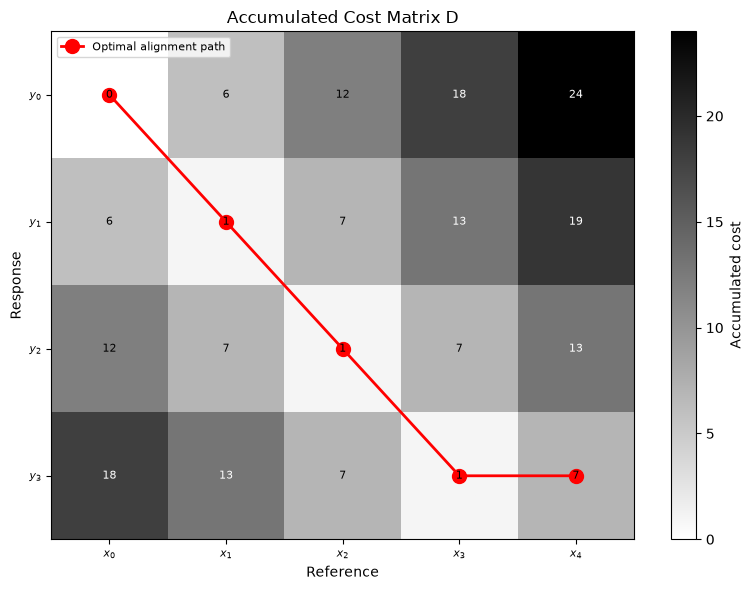

In [13]:
plot_cost_matrix(D, operations, response["notes"], reference["notes"])

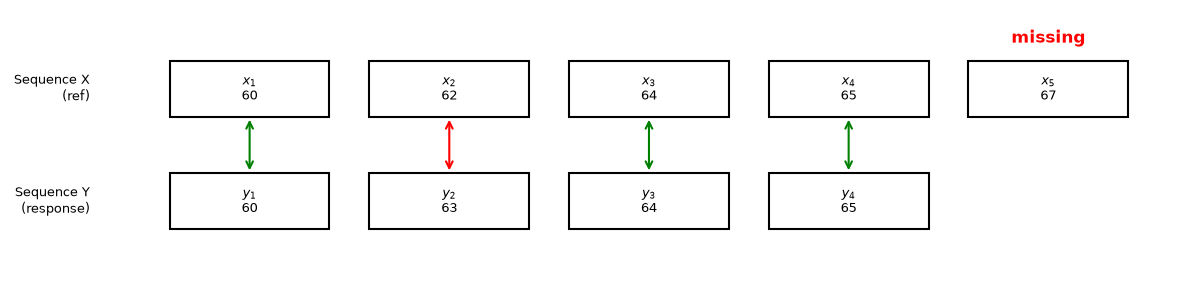

In [14]:
plot_alignment_arrows(operations, response["notes"], reference["notes"])